### Exploratory Data Analysis - Aviation Accidents

This notebook contains comprehensive EDA to understand patterns and trends in aviation accidents using `CleanedAviationData.csv` file.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load preprocessed data
df = pd.read_csv('data/CleanedAviationData.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (88882, 22)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,...,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Year,Month,Total.Injuries
0,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,Non-Fatal,Substantial,Cessna,140,...,Personal,0.0,0.0,0.0,2.0,VMC,Takeoff,1982,January,0.0
1,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,Non-Fatal,Substantial,Cessna,401B,...,Business,0.0,0.0,0.0,2.0,IMC,Landing,1982,January,0.0
2,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,Non-Fatal,Substantial,North American,NAVION L-17B,...,Personal,0.0,0.0,3.0,0.0,IMC,Cruise,1982,January,3.0
3,20020909X01559,Accident,FTW82DA034,1982-01-01,"HOBBS, NM",United States,Non-Fatal,Substantial,Piper,PA-28-161,...,Personal,0.0,0.0,0.0,1.0,VMC,Approach,1982,January,0.0
4,20020909X01558,Accident,ATL82DKJ10,1982-01-01,"TUSKEGEE, AL",United States,Non-Fatal,Substantial,Beech,V35B,...,Personal,0.0,0.0,0.0,1.0,VMC,Landing,1982,January,0.0


## Objective 1: Historical Trends Analysis

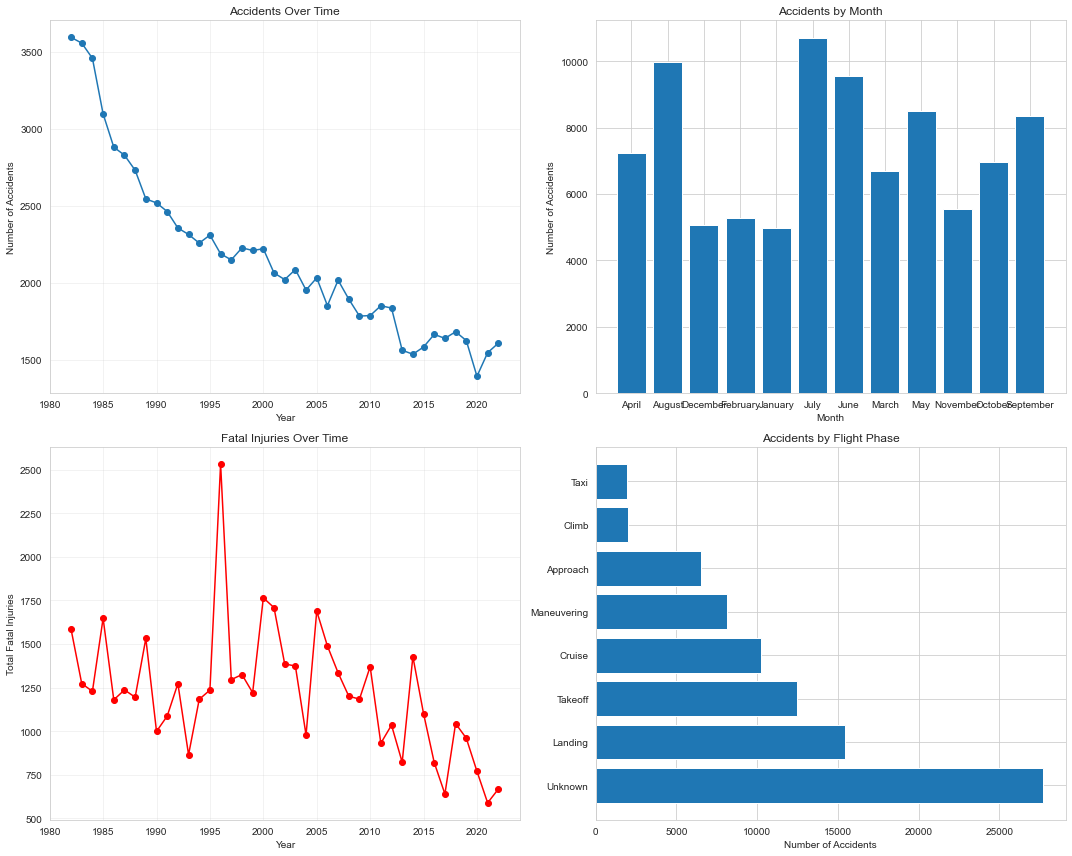

In [4]:
# Create comprehensive trend analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accidents per year
yearly_accidents = df.groupby('Year').size()
axes[0,0].plot(yearly_accidents.index, yearly_accidents.values, marker='o')
axes[0,0].set_title('Accidents Over Time')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Accidents')
axes[0,0].grid(True, alpha=0.3)

# Monthly patterns
monthly_accidents = df.groupby('Month').size()
axes[0,1].bar(monthly_accidents.index, monthly_accidents.values)
axes[0,1].set_title('Accidents by Month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Number of Accidents')

# Fatal injuries over time
yearly_fatalities = df.groupby('Year')['Total.Fatal.Injuries'].sum()
axes[1,0].plot(yearly_fatalities.index, yearly_fatalities.values, color='red', marker='o')
axes[1,0].set_title('Fatal Injuries Over Time')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Total Fatal Injuries')
axes[1,0].grid(True, alpha=0.3)

# Flight phase analysis
phase_counts = df['Broad.phase.of.flight'].value_counts().head(8)
axes[1,1].barh(range(len(phase_counts)), phase_counts.values)
axes[1,1].set_yticks(range(len(phase_counts)))
axes[1,1].set_yticklabels(phase_counts.index)
axes[1,1].set_title('Accidents by Flight Phase')
axes[1,1].set_xlabel('Number of Accidents')

plt.tight_layout()
plt.show(); 

The top left visualization is a line plot showing the number of accidents per year from 1982 onwards and shows a declining trend in total accidents over the decades. The positive trend likely reflects significant improvements in aviation safety including better aircraft technology, enhanced pilot training and improved air traffic control systems among others. 

The top right visualization reveals seasonal patterns with higher accident rates during summer months likely due to increased recreational flying activity, more general aviation flights and challenging weather conditions that are common during warmer months. 

The bottom left visualization shows the trend in fatality rates across the years indicating not only fewer accidents but also improved aircraft safety features or enhanced susrvuval equipment that reduce the severity of accidents when they do occur. 

The bottom right visualization identifies critical flight phases where most accidents occur and they are inherently high-risk because they involve complex maneuvers, proximity to ground, and require precise pilot control. Landing and takeoff are particularly vulnerable due to weather sensitivity and the need for split-second decision making. 

## Objective 2: Aircraft and Engine Analysis

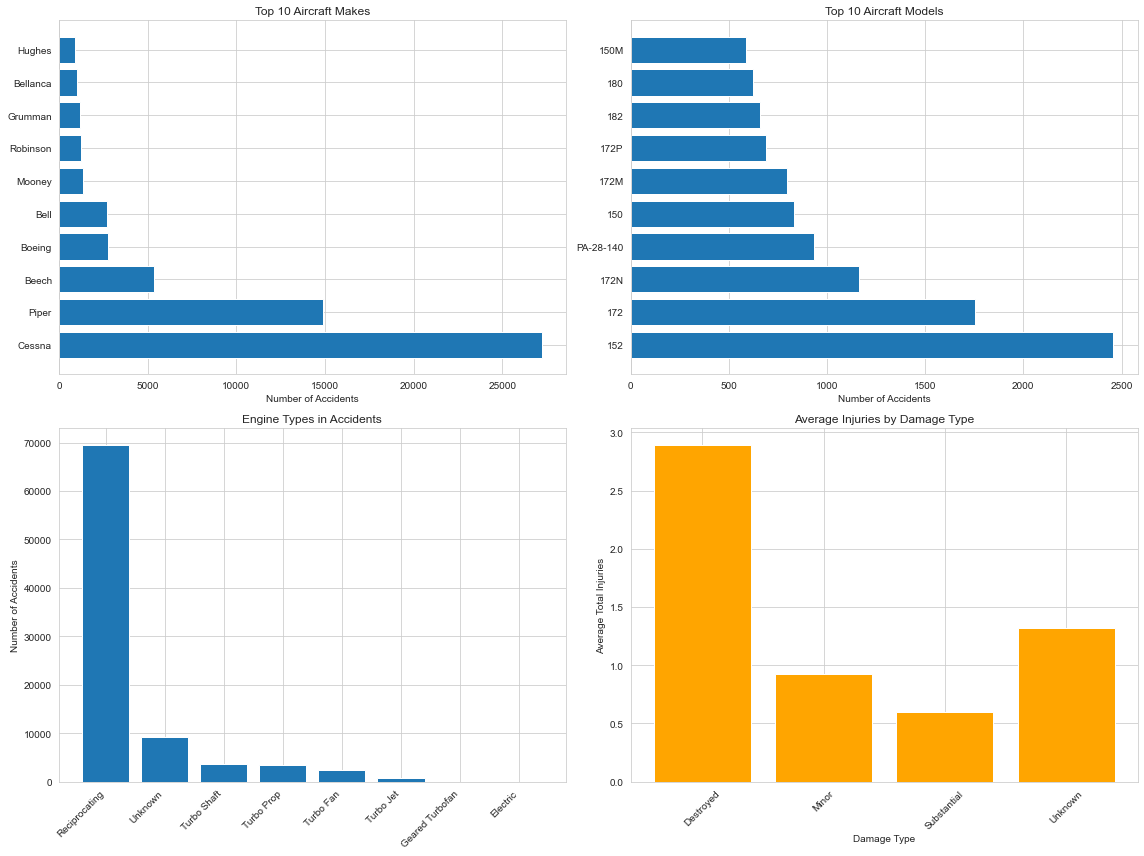

In [6]:
# Aircraft analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top aircraft makes
top_makes = df['Make'].value_counts().head(10)
axes[0,0].barh(range(len(top_makes)), top_makes.values)
axes[0,0].set_yticks(range(len(top_makes)))
axes[0,0].set_yticklabels(top_makes.index)
axes[0,0].set_title('Top 10 Aircraft Makes')
axes[0,0].set_xlabel('Number of Accidents')

# Top models
top_models = df['Model'].value_counts().head(10)
axes[0,1].barh(range(len(top_models)), top_models.values)
axes[0,1].set_yticks(range(len(top_models)))
axes[0,1].set_yticklabels(top_models.index)
axes[0,1].set_title('Top 10 Aircraft Models')
axes[0,1].set_xlabel('Number of Accidents')

# Engine types
engine_counts = df['Engine.Type'].value_counts().head(8)
axes[1,0].bar(range(len(engine_counts)), engine_counts.values)
axes[1,0].set_xticks(range(len(engine_counts)))
axes[1,0].set_xticklabels(engine_counts.index, rotation=45, ha='right')
axes[1,0].set_title('Engine Types in Accidents')
axes[1,0].set_ylabel('Number of Accidents')

# Damage vs Injuries
damage_injury = df.groupby('Aircraft.damage')['Total.Injuries'].mean()
axes[1,1].bar(damage_injury.index, damage_injury.values, color='orange')
axes[1,1].set_title('Average Injuries by Damage Type')
axes[1,1].set_xlabel('Damage Type')
axes[1,1].set_ylabel('Average Total Injuries')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Objective 3: Weather Impact Analysis

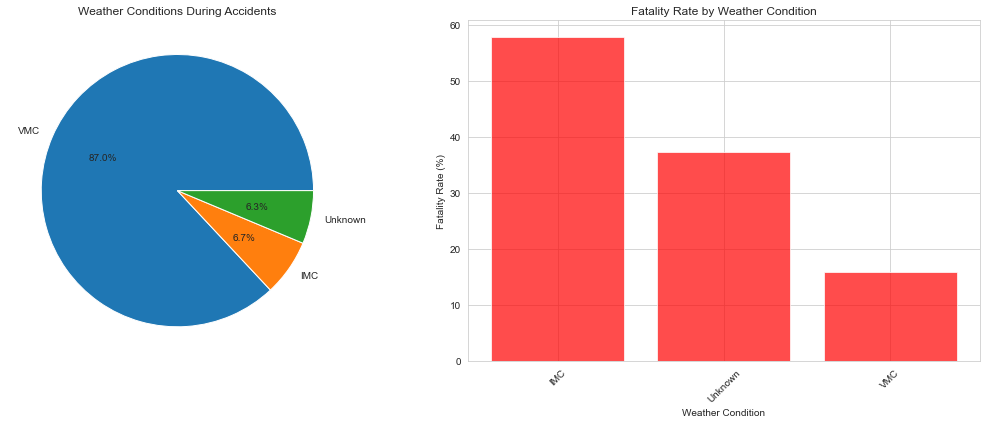

In [ ]:
# Create Is_Fatal column
df['Is_Fatal'] = (df['Total.Fatal.Injuries'] > 0).astype(int)

# Weather conditions analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Weather distribution
weather_counts = df['Weather.Condition'].value_counts()
axes[0].pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%')
axes[0].set_title('Weather Conditions During Accidents')

# Weather vs Fatality rate
weather_fatality = df.groupby('Weather.Condition')['Is_Fatal'].mean() * 100
axes[1].bar(weather_fatality.index, weather_fatality.values, color='red', alpha=0.7)
axes[1].set_title('Fatality Rate by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Fatality Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Objective 4: Damage Pattern Analysis

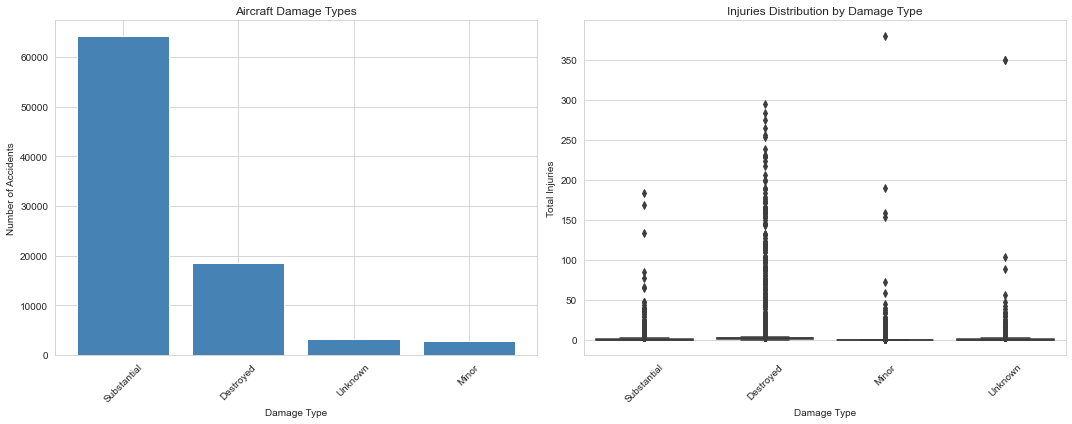

In [9]:
# Damage analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Damage distribution
damage_counts = df['Aircraft.damage'].value_counts()
axes[0].bar(damage_counts.index, damage_counts.values, color='steelblue')
axes[0].set_title('Aircraft Damage Types')
axes[0].set_xlabel('Damage Type')
axes[0].set_ylabel('Number of Accidents')
axes[0].tick_params(axis='x', rotation=45)

# Damage vs Total Injuries boxplot
sns.boxplot(data=df, x='Aircraft.damage', y='Total.Injuries', ax=axes[1])
axes[1].set_title('Injuries Distribution by Damage Type')
axes[1].set_xlabel('Damage Type')
axes[1].set_ylabel('Total Injuries')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show(); 

## Key Insights Summary

In [10]:
print("=== KEY INSIGHTS ===")
print(f"1. Accident Trends:")
print(f"   - Peak accident year: {yearly_accidents.idxmax()} ({yearly_accidents.max()} accidents)")
print(f"   - Most recent year: {yearly_accidents.index[-1]} ({yearly_accidents.iloc[-1]} accidents)")
print(f"   - Highest risk month: {monthly_accidents.idxmax()} ({monthly_accidents.max()} accidents)")

print(f"\n2. Aircraft Analysis:")
print(f"   - Most involved make: {top_makes.index[0]} ({top_makes.iloc[0]} accidents)")
print(f"   - Most common engine: {engine_counts.index[0]} ({engine_counts.iloc[0]} accidents)")

print(f"\n3. Weather Impact:")
print(f"   - Most common weather: {weather_counts.index[0]} ({weather_counts.iloc[0]} accidents)")
print(f"   - Highest fatality rate weather: {weather_fatality.idxmax()} ({weather_fatality.max():.1f}%)")

print(f"\n4. Damage Patterns:")
print(f"   - Most common damage: {damage_counts.index[0]} ({damage_counts.iloc[0]} accidents)")
print(f"   - Fatal accident rate: {(df['Is_Fatal'].sum() / len(df) * 100):.1f}%")

=== KEY INSIGHTS ===
1. Accident Trends:
   - Peak accident year: 1982 (3593 accidents)
   - Most recent year: 2022 (1607 accidents)
   - Highest risk month: July (10697 accidents)

2. Aircraft Analysis:
   - Most involved make: Cessna (27209 accidents)
   - Most common engine: Reciprocating (69525 accidents)

3. Weather Impact:
   - Most common weather: VMC (77301 accidents)
   - Highest fatality rate weather: IMC (57.9%)

4. Damage Patterns:
   - Most common damage: Substantial (64147 accidents)
   - Fatal accident rate: 20.0%
